## Imports & Paths

In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import random

# ── Paths ──────────────────────────────────────────────────
PREPROCESSED  = Path(r"C:\Users\Admin\Desktop\madhura\nnunet_project\preprocessed")
PREP_IMGS_TR  = PREPROCESSED / "imagesTr"
PREP_LBLS_TR  = PREPROCESSED / "labelsTr"
PREP_IMGS_TS  = PREPROCESSED / "imagesTs"
RESULTS_PATH  = Path(r"C:\Users\Admin\Desktop\madhura\nnunet_project\results\03_dataset")
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# ── All valid training cases ────────────────────────────────
ALL_CASES = sorted([
    f.stem for f in PREP_IMGS_TR.glob("*.npy")
])

print("✅ Imports done")
print(f"✅ Results folder: {RESULTS_PATH}")
print(f"✅ Total training cases: {len(ALL_CASES)}")
print(f"   Cases: {ALL_CASES}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "C:\Users\Admin\.conda\envs\nnunetv2env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\Admin\.conda\envs\nnunetv2env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\Admin\.conda\envs\nnunetv2env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Admin\.conda\envs\nnunetv2env\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    a

✅ Imports done
✅ Results folder: C:\Users\Admin\Desktop\madhura\nnunet_project\results\03_dataset
✅ Total training cases: 20
   Cases: ['la_003', 'la_004', 'la_005', 'la_007', 'la_009', 'la_010', 'la_011', 'la_014', 'la_016', 'la_017', 'la_018', 'la_019', 'la_020', 'la_021', 'la_022', 'la_023', 'la_024', 'la_026', 'la_029', 'la_030']


## Train/Validation Split

In [2]:
random.seed(42)
np.random.seed(42)

# ── 80/20 split → 16 train, 4 validation ──────────────────
shuffled = ALL_CASES.copy()
random.shuffle(shuffled)

n_val        = 4
TRAIN_CASES  = sorted(shuffled[n_val:])
VAL_CASES    = sorted(shuffled[:n_val])

print("=" * 55)
print("TRAIN / VALIDATION SPLIT")
print("=" * 55)
print(f"Total cases      : {len(ALL_CASES)}")
print(f"Training cases   : {len(TRAIN_CASES)} → {TRAIN_CASES}")
print(f"Validation cases : {len(VAL_CASES)}  → {VAL_CASES}")

TRAIN / VALIDATION SPLIT
Total cases      : 20
Training cases   : 16 → ['la_003', 'la_004', 'la_005', 'la_007', 'la_011', 'la_014', 'la_016', 'la_017', 'la_018', 'la_019', 'la_020', 'la_021', 'la_023', 'la_024', 'la_026', 'la_029']
Validation cases : 4  → ['la_009', 'la_010', 'la_022', 'la_030']


## Define Patch Size & Dataset Class

In [4]:
# ── Patch size (nnU-Net style 3D patches) ─────────────────
PATCH_SIZE = (128, 128, 128)  # 3D cubic patch

class AtriumDataset(Dataset):
    """
    PyTorch Dataset for Left Atrium Segmentation.
    - Loads preprocessed .npy volumes
    - Randomly samples 3D patches (training)
    - Returns full volume (validation)
    - Applies augmentation (training only)
    """
    def __init__(self, case_ids, img_dir, lbl_dir, 
                 patch_size=PATCH_SIZE, mode="train"):
        self.case_ids   = case_ids
        self.img_dir    = Path(img_dir)
        self.lbl_dir    = Path(lbl_dir)
        self.patch_size = patch_size
        self.mode       = mode  # "train" or "val"

        # Pre-load all volumes into memory (small dataset)
        print(f"Loading {len(case_ids)} {mode} volumes into memory...")
        self.images = []
        self.labels = []
        for case_id in case_ids:
            img = np.load(self.img_dir / f"{case_id}.npy")
            lbl = np.load(self.lbl_dir / f"{case_id}.npy")
            self.images.append(img)
            self.labels.append(lbl)
            print(f"  Loaded {case_id} | img={img.shape} | "
                  f"atrium={100*(lbl==1).mean():.3f}%")
        print(f"✅ {mode} dataset ready — {len(self.images)} volumes\n")

    def __len__(self):
        # Each volume yields multiple patches per epoch
        return len(self.case_ids) * (10 if self.mode == "train" else 1)

    def _random_patch(self, img, lbl):
        """Sample a random 3D patch, biased toward atrium voxels."""
        D, H, W = img.shape
        pd, ph, pw = self.patch_size

        # 50% chance: center patch on a random atrium voxel
        atrium_voxels = np.argwhere(lbl == 1)
        if len(atrium_voxels) > 0 and random.random() < 0.5:
            center = atrium_voxels[random.randint(0, len(atrium_voxels)-1)]
            cd, ch, cw = center
        else:
            cd = random.randint(pd//2, D - pd//2)
            ch = random.randint(ph//2, H - ph//2)
            cw = random.randint(pw//2, W - pw//2)

        # Compute patch bounds (clamp to volume)
        d0 = max(0, min(cd - pd//2, D - pd))
        h0 = max(0, min(ch - ph//2, H - ph))
        w0 = max(0, min(cw - pw//2, W - pw))

        img_patch = img[d0:d0+pd, h0:h0+ph, w0:w0+pw]
        lbl_patch = lbl[d0:d0+pd, h0:h0+ph, w0:w0+pw]
        return img_patch, lbl_patch

    def _augment(self, img, lbl):
        """Simple augmentation: random flips along each axis."""
        for axis in range(3):
            if random.random() < 0.5:
                img = np.flip(img, axis=axis).copy()
                lbl = np.flip(lbl, axis=axis).copy()

        # Random intensity scaling (±10%)
        scale = random.uniform(0.9, 1.1)
        img   = img * scale
        return img, lbl

    def _center_patch(self, img, lbl):
        """Extract center patch for validation."""
        D, H, W = img.shape
        pd, ph, pw = self.patch_size
        d0 = (D - pd) // 2
        h0 = (H - ph) // 2
        w0 = (W - pw) // 2
        return img[d0:d0+pd, h0:h0+ph, w0:w0+pw], \
               lbl[d0:d0+pd, h0:h0+ph, w0:w0+pw]

    def __getitem__(self, idx):
        # Select volume (cycle through cases)
        vol_idx = idx % len(self.case_ids)
        img = self.images[vol_idx].copy()
        lbl = self.labels[vol_idx].copy()

        if self.mode == "train":
            img, lbl = self._random_patch(img, lbl)
            img, lbl = self._augment(img, lbl)
        else:
            img, lbl = self._center_patch(img, lbl)

        # Add channel dim → (1, D, H, W)
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        lbl = t

## Instantiate Train & Validation Datasets

In [5]:
train_dataset = AtriumDataset(
    case_ids   = TRAIN_CASES,
    img_dir    = PREP_IMGS_TR,
    lbl_dir    = PREP_LBLS_TR,
    patch_size = PATCH_SIZE,
    mode       = "train"
)

val_dataset = AtriumDataset(
    case_ids   = VAL_CASES,
    img_dir    = PREP_IMGS_TR,
    lbl_dir    = PREP_LBLS_TR,
    patch_size = PATCH_SIZE,
    mode       = "val"
)

print("=" * 55)
print("DATASET SUMMARY")
print("=" * 55)
print(f"Train dataset length : {len(train_dataset)} patches")
print(f"Val dataset length   : {len(val_dataset)} patches")
print(f"Patch size           : {PATCH_SIZE}")

Loading 16 train volumes into memory...
  Loaded la_003 | img=(320, 320, 153) | atrium=0.313%
  Loaded la_004 | img=(320, 320, 153) | atrium=0.412%
  Loaded la_005 | img=(320, 320, 153) | atrium=0.410%
  Loaded la_007 | img=(320, 320, 153) | atrium=0.387%
  Loaded la_011 | img=(320, 320, 153) | atrium=0.411%
  Loaded la_014 | img=(320, 320, 153) | atrium=0.481%
  Loaded la_016 | img=(320, 320, 153) | atrium=0.339%
  Loaded la_017 | img=(320, 320, 153) | atrium=0.267%
  Loaded la_018 | img=(320, 320, 153) | atrium=0.283%
  Loaded la_019 | img=(320, 320, 153) | atrium=0.382%
  Loaded la_020 | img=(320, 320, 153) | atrium=0.225%
  Loaded la_021 | img=(320, 320, 153) | atrium=0.275%
  Loaded la_023 | img=(320, 320, 153) | atrium=0.303%
  Loaded la_024 | img=(320, 320, 153) | atrium=0.327%
  Loaded la_026 | img=(320, 320, 153) | atrium=0.379%
  Loaded la_029 | img=(320, 320, 153) | atrium=0.228%
✅ train dataset ready — 16 volumes

Loading 4 val volumes into memory...
  Loaded la_009 | img=(

## Create DataLoaders

In [7]:
import torch
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

PATCH_SIZE    = (128, 128, 128)
PREP_IMGS_TR  = Path(r"C:\Users\Admin\Desktop\madhura\nnunet_project\preprocessed\imagesTr")
PREP_LBLS_TR  = Path(r"C:\Users\Admin\Desktop\madhura\nnunet_project\preprocessed\labelsTr")

class AtriumDataset(Dataset):
    def __init__(self, case_ids, img_dir, lbl_dir,
                 patch_size=PATCH_SIZE, mode="train"):
        self.case_ids   = case_ids
        self.img_dir    = Path(img_dir)
        self.lbl_dir    = Path(lbl_dir)
        self.patch_size = patch_size
        self.mode       = mode

        print(f"Loading {len(case_ids)} {mode} volumes...")
        self.images, self.labels = [], []
        for case_id in case_ids:
            img = np.load(self.img_dir / f"{case_id}.npy")
            lbl = np.load(self.lbl_dir / f"{case_id}.npy")
            self.images.append(img)
            self.labels.append(lbl)
        print(f"✅ {mode} dataset ready — {len(self.images)} volumes\n")

    def __len__(self):
        return len(self.case_ids) * (10 if self.mode == "train" else 1)

    def _random_patch(self, img, lbl):
        D, H, W    = img.shape
        pd, ph, pw = self.patch_size
        atrium_voxels = np.argwhere(lbl == 1)
        if len(atrium_voxels) > 0 and random.random() < 0.5:
            center = atrium_voxels[random.randint(0, len(atrium_voxels)-1)]
            cd, ch, cw = center
        else:
            cd = random.randint(pd//2, D - pd//2)
            ch = random.randint(ph//2, H - ph//2)
            cw = random.randint(pw//2, W - pw//2)
        d0 = max(0, min(cd - pd//2, D - pd))
        h0 = max(0, min(ch - ph//2, H - ph))
        w0 = max(0, min(cw - pw//2, W - pw))
        return img[d0:d0+pd, h0:h0+ph, w0:w0+pw], \
               lbl[d0:d0+pd, h0:h0+ph, w0:w0+pw]

    def _augment(self, img, lbl):
        for axis in range(3):
            if random.random() < 0.5:
                img = np.flip(img, axis=axis).copy()
                lbl = np.flip(lbl, axis=axis).copy()
        img = img * random.uniform(0.9, 1.1)
        return img, lbl

    def _center_patch(self, img, lbl):
        D, H, W    = img.shape
        pd, ph, pw = self.patch_size
        d0 = (D - pd) // 2
        h0 = (H - ph) // 2
        w0 = (W - pw) // 2
        return img[d0:d0+pd, h0:h0+ph, w0:w0+pw], \
               lbl[d0:d0+pd, h0:h0+ph, w0:w0+pw]

    def __getitem__(self, idx):
        vol_idx = idx % len(self.case_ids)
        img = self.images[vol_idx].copy()
        lbl = self.labels[vol_idx].copy()
        if self.mode == "train":
            img, lbl = self._random_patch(img, lbl)
            img, lbl = self._augment(img, lbl)
        else:
            img, lbl = self._center_patch(img, lbl)
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        lbl = torch.tensor(lbl, dtype=torch.long)
        return img, lbl

# ── Reinstantiate ──────────────────────────────────────────
TRAIN_CASES = ['la_003','la_004','la_005','la_007','la_011','la_014',
               'la_016','la_017','la_018','la_019','la_020','la_021',
               'la_023','la_024','la_026','la_029']
VAL_CASES   = ['la_009','la_010','la_022','la_030']

train_dataset = AtriumDataset(TRAIN_CASES, PREP_IMGS_TR, PREP_LBLS_TR, mode="train")
val_dataset   = AtriumDataset(VAL_CASES,   PREP_IMGS_TR, PREP_LBLS_TR, mode="val")

train_loader  = DataLoader(train_dataset, batch_size=2, shuffle=True,
                           num_workers=0, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=1, shuffle=False,
                           num_workers=0, pin_memory=True)

# ── Test one batch ─────────────────────────────────────────
img_batch, lbl_batch = next(iter(train_loader))

print("=" * 55)
print("DATALOADER TEST")
print("=" * 55)
print(f"Train batches/epoch : {len(train_loader)}")
print(f"Val batches/epoch   : {len(val_loader)}")
print(f"\nBatch shapes:")
print(f"  Image : {img_batch.shape}  dtype={img_batch.dtype}")
print(f"  Label : {lbl_batch.shape}  dtype={lbl_batch.dtype}")
print(f"\nImage stats:")
print(f"  min={img_batch.min():.3f}  max={img_batch.max():.3f}  "
      f"mean={img_batch.mean():.3f}")
print(f"\nLabel unique values   : {lbl_batch.unique()}")
print(f"Atrium voxels/batch   : {(lbl_batch==1).sum().item()} / "
      f"{lbl_batch.numel()}")

Loading 16 train volumes...
✅ train dataset ready — 16 volumes

Loading 4 val volumes...
✅ val dataset ready — 4 volumes

DATALOADER TEST
Train batches/epoch : 80
Val batches/epoch   : 4

Batch shapes:
  Image : torch.Size([2, 1, 128, 128, 128])  dtype=torch.float32
  Label : torch.Size([2, 128, 128, 128])  dtype=torch.int64

Image stats:
  min=-0.990  max=5.677  mean=0.127

Label unique values   : tensor([0, 1])
Atrium voxels/batch   : 64412 / 4194304


## Visualize Training Patches & Augmentation

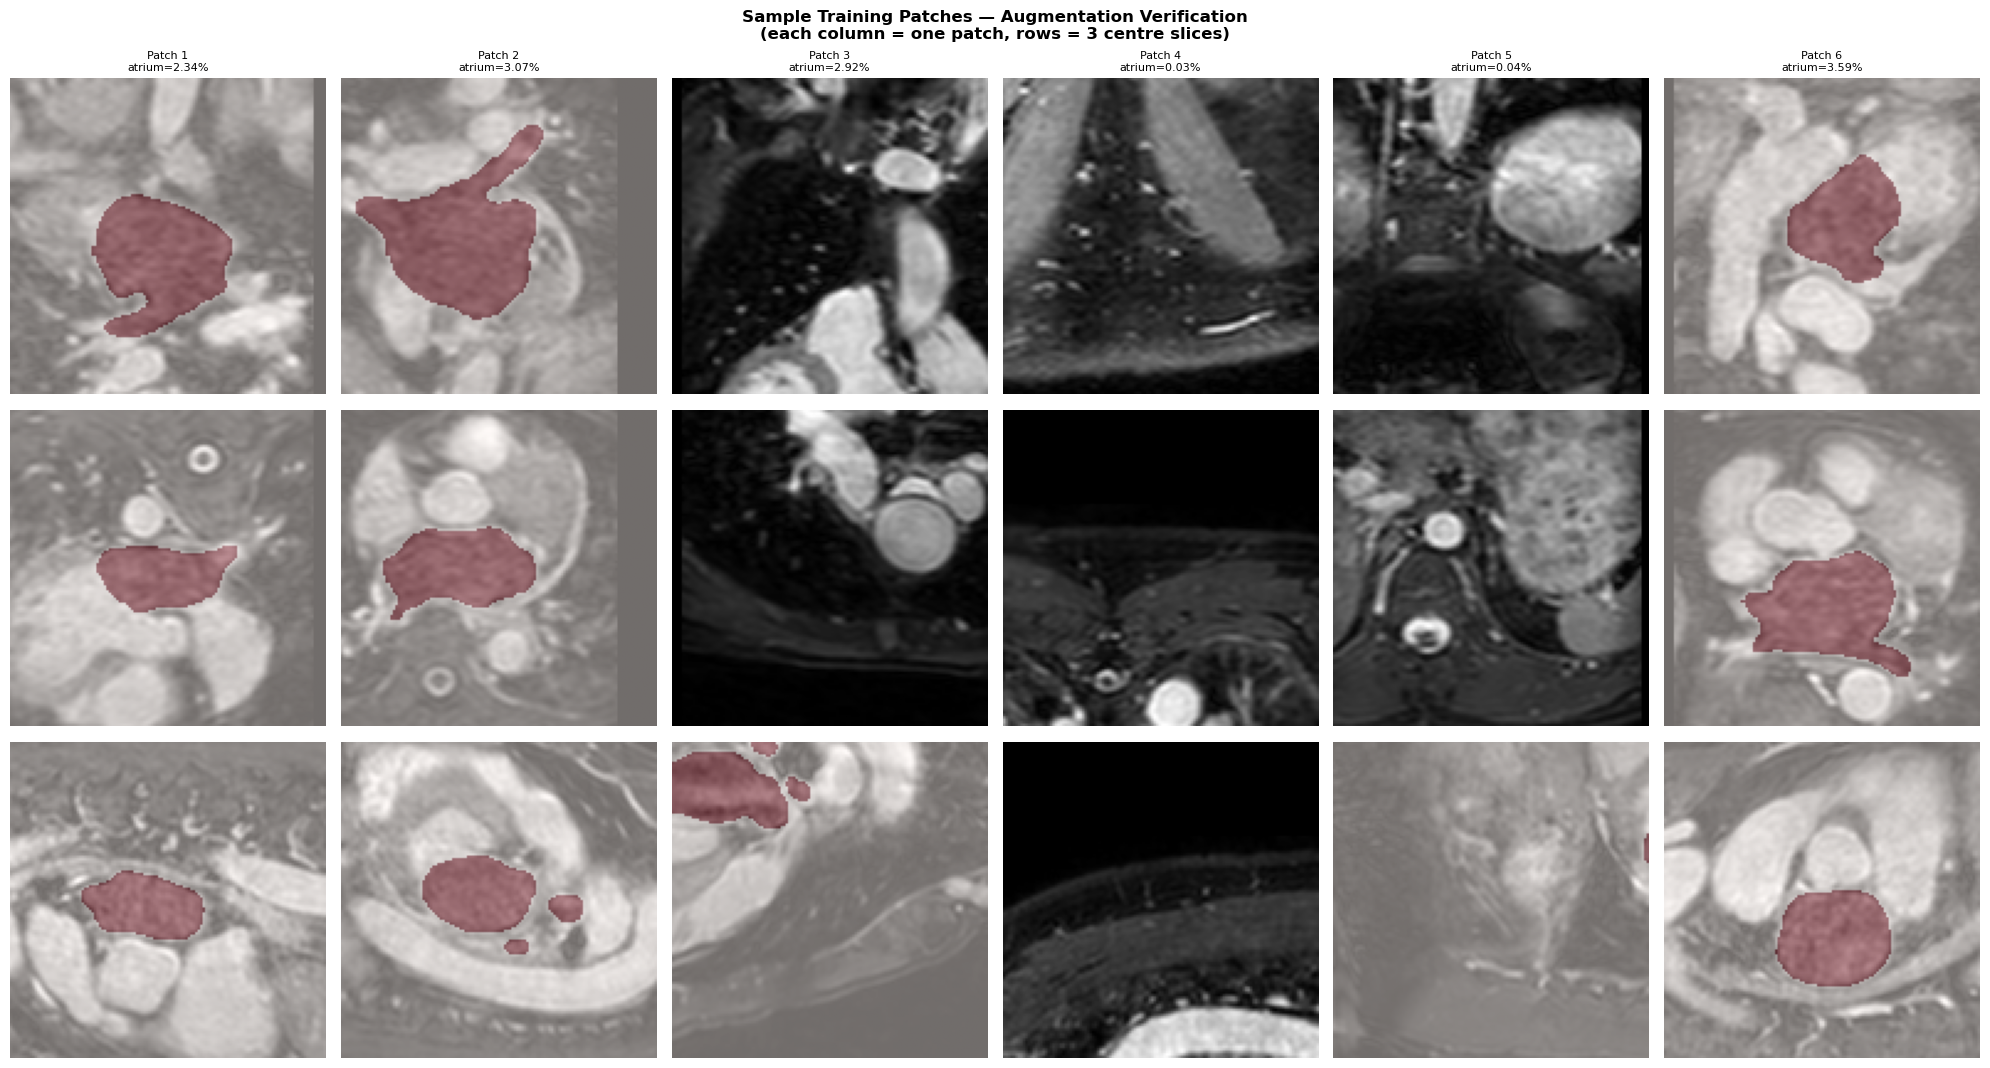

✅ Plot saved to:
   C:\Users\Admin\Desktop\madhura\nnunet_project\results\03_dataset\sample_patches.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

RESULTS_PATH = Path(r"C:\Users\Admin\Desktop\madhura\nnunet_project\results\03_dataset")

# Fix: convert via tolist or float() to avoid numpy compat issue
def tensor_to_np(t):
    return np.array(t.tolist(), dtype=np.float32)

fig, axes = plt.subplots(3, 6, figsize=(20, 11))
fig.suptitle("Sample Training Patches — Augmentation Verification\n"
             "(each column = one patch, rows = 3 centre slices)",
             fontsize=12, fontweight="bold")

patch_imgs, patch_lbls = [], []
for i in range(6):
    img, lbl = train_dataset[i]
    patch_imgs.append(img)
    patch_lbls.append(lbl)

for col in range(6):
    img = tensor_to_np(patch_imgs[col].squeeze(0))  # (128,128,128)
    lbl = tensor_to_np(patch_lbls[col])              # (128,128,128)

    slices = [
        (img[64, :, :], lbl[64, :, :]),
        (img[:, 64, :], lbl[:, 64, :]),
        (img[:, :, 64], lbl[:, :, 64]),
    ]

    row_titles = ["Axial", "Coronal", "Sagittal"]
    atrium_pct = 100 * (lbl == 1).mean()

    for row, (img_sl, lbl_sl) in enumerate(slices):
        ax = axes[row, col]
        ax.imshow(img_sl, cmap="gray", origin="lower")
        if lbl_sl.sum() > 0:
            ax.imshow(lbl_sl, cmap="Reds", alpha=0.45,
                      origin="lower", vmin=0, vmax=1)
        if row == 0:
            ax.set_title(f"Patch {col+1}\natrium={atrium_pct:.2f}%",
                         fontsize=8)
        if col == 0:
            ax.set_ylabel(row_titles[row], fontsize=9)
        ax.axis("off")

plt.tight_layout()
save_path = RESULTS_PATH / "sample_patches.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Plot saved to:\n   {save_path}")

## Final Summary

In [11]:
print("=" * 55)
print("  DATASET NOTEBOOK COMPLETE")
print("=" * 55)

print("\n📋 DATASET CLASS")
print("  Class         : AtriumDataset (PyTorch Dataset)")
print("  Patch size    : (128, 128, 128)")
print("  Train patches : 160 per epoch (10 per volume)")
print("  Val patches   : 4 per epoch (1 per volume)")

print("\n📋 SPLIT")
print(f"  Train cases   : {len(TRAIN_CASES)} → {TRAIN_CASES}")
print(f"  Val cases     : {len(VAL_CASES)}  → {VAL_CASES}")

print("\n📋 DATALOADERS")
print("  Train loader  : batch_size=2, shuffle=True")
print("  Val loader    : batch_size=1, shuffle=False")
print("  num_workers   : 0 (Windows compatible)")

print("\n📋 AUGMENTATION (train only)")
print("  Random flips  : along all 3 axes (p=0.5 each)")
print("  Intensity     : random scale ±10%")
print("  Patch sampling: 50% atrium-biased, 50% random")

print("\n📋 BATCH FORMAT")
print("  Image shape   : (B, 1, 128, 128, 128) float32")
print("  Label shape   : (B, 128, 128, 128)    int64")

print("\n📁 SAVED OUTPUTS")
for f in sorted(RESULTS_PATH.glob("*")):
    print(f"  ✅ {f.name}")

print("\n▶️  NEXT NOTEBOOK: 04_model.ipynb")

  DATASET NOTEBOOK COMPLETE

📋 DATASET CLASS
  Class         : AtriumDataset (PyTorch Dataset)
  Patch size    : (128, 128, 128)
  Train patches : 160 per epoch (10 per volume)
  Val patches   : 4 per epoch (1 per volume)

📋 SPLIT
  Train cases   : 16 → ['la_003', 'la_004', 'la_005', 'la_007', 'la_011', 'la_014', 'la_016', 'la_017', 'la_018', 'la_019', 'la_020', 'la_021', 'la_023', 'la_024', 'la_026', 'la_029']
  Val cases     : 4  → ['la_009', 'la_010', 'la_022', 'la_030']

📋 DATALOADERS
  Train loader  : batch_size=2, shuffle=True
  Val loader    : batch_size=1, shuffle=False
  num_workers   : 0 (Windows compatible)

📋 AUGMENTATION (train only)
  Random flips  : along all 3 axes (p=0.5 each)
  Intensity     : random scale ±10%
  Patch sampling: 50% atrium-biased, 50% random

📋 BATCH FORMAT
  Image shape   : (B, 1, 128, 128, 128) float32
  Label shape   : (B, 128, 128, 128)    int64

📁 SAVED OUTPUTS
  ✅ sample_patches.png

▶️  NEXT NOTEBOOK: 04_model.ipynb
